# 2D FEM Solver

We aim to solve the differential linear equation

\begin{equation}
-\frac{\partial}{\partial x}\left(\alpha_1(x, y) \frac{\partial \Phi(x, y)}{\partial x}\right)-\frac{\partial}{\partial y}\left(\alpha_2(x, y) \frac{\partial \Phi(x, y)}{\partial y}\right)+\beta(x, y) \Phi(x, y)=f(x, y)
\end{equation}

on the area given by the following image.

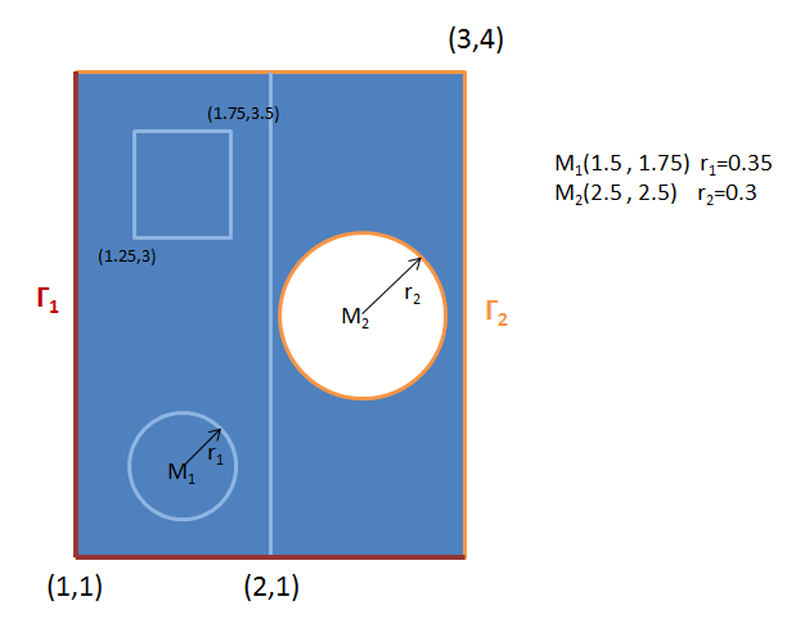

## Dirichtlet

\begin{equation}
\Phi(x, y) = x^2 -y^2 +1 \quad x,y \in \Gamma_1
\end{equation}

In [1]:
import numpy as np

import functions as myfunc

## Assign Parameters from Task

In [2]:
DOMAIN_KNOTS = np.loadtxt("Lösung/Netz2D_p.dat")
ELEMENTS = np.loadtxt("Lösung/Netz2D_t.dat", dtype=int) # ! dtype is important here.

def alpha1(x, y):
    if 1.25 <= x <= 1.75 and 3 <= y <= 3.5:
        return 0.01
    else:
        return 5 * y * np.power(x, 2)
    
def alpha2(x, y):
    return np.power(y, 2)

def beta(x, y):
    left_hand_side = np.power((x-1.5),2) + np.power((y-1.75), 2) 
    if left_hand_side <= 0.35**2:
        return 500
    else:
        return 5
    
def rhs(x, y):
    if x >= 2:
        return 10 * x * y
    else:
        return 0
    
# Dirichlet Boundary Conditions
DIRICHLET_INDICES = np.loadtxt("Lösung/Netz2D_dr_a).dat", dtype=int)
def dirichlet(x, y):
    return np.power(x, 2) - np.power(y, 2) + 1

## My Work

In [3]:
number_of_elements = myfunc.get_number_of_elements(ELEMENTS)
print(f"Number of elements: {number_of_elements}")

Number of elements: 2400


In [4]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(DOMAIN_KNOTS, ELEMENTS, alpha1, alpha2, beta, rhs)

In [5]:
reduced_maatrix, reduced_rhs = myfunc.insert_dirichlet_values(DOMAIN_KNOTS, DIRICHLET_INDICES, dirichlet, stiffness_matrix, load_vector)

In [6]:
own_solution = myfunc.solve_system(DOMAIN_KNOTS, reduced_maatrix, reduced_rhs)

c:\Users\Jax\Coding\Finite-Element-Solver\Übungsaufgaben\Übung 2D\functions.py:368: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  solution_vector = spsolve(stiffness_matrix, load_vector)


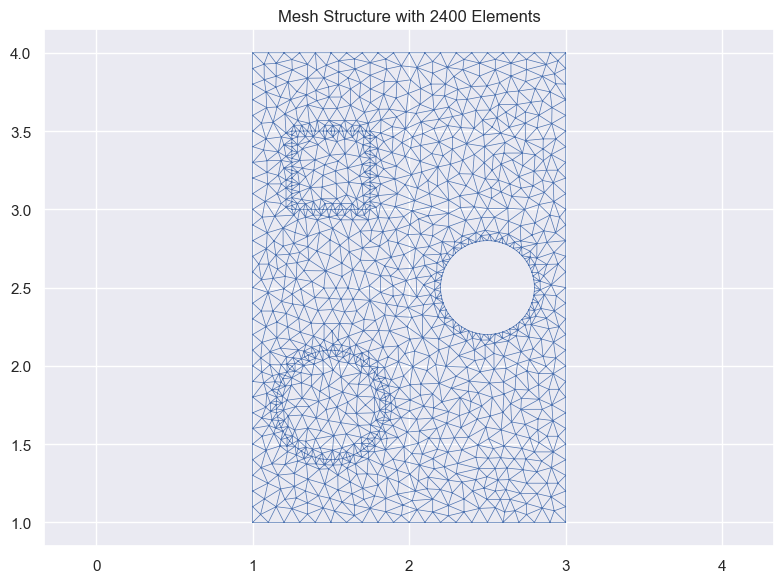

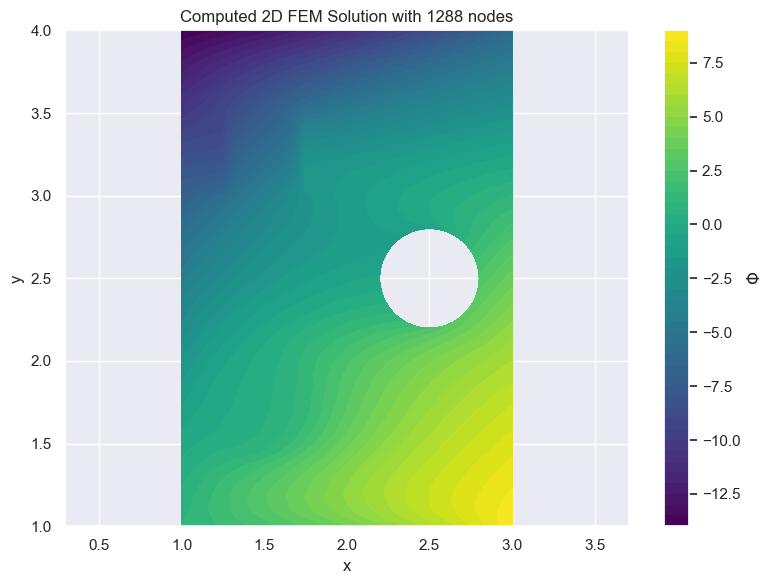

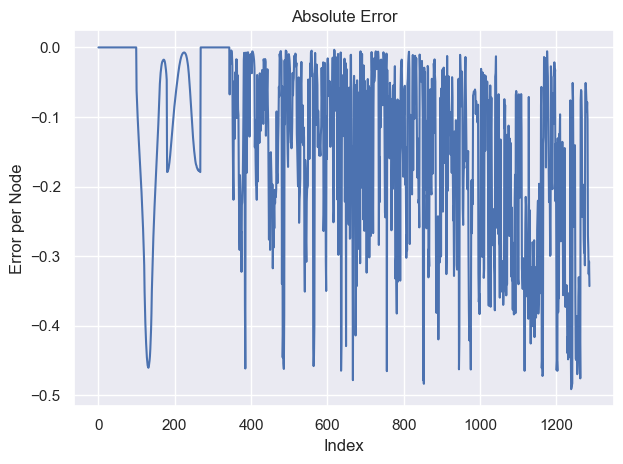

In [7]:
myfunc.plot_result(ELEMENTS, own_solution, "Lösung/Netz2D_LoesungA.dat", levels=50)